In [1]:
import numpy as np
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import json
import cftime
from cftime import DatetimeNoLeap
from scipy import stats
from scipy.interpolate import interp1d
import dask
from tqdm import tqdm
#from mpl_axes_aligner import align
from xmip.preprocessing import rename_cmip6
%matplotlib inline
#import xesmf as xe
import matplotlib
from utils import QACC_utils
#from utils.config import model, min_lat, max_lat, min_year_late_cent, max_year_late_cent
##### SETTINGS
model = 'UKESM1-0-LL'
regions = ['Arctic', 'Tropics']
lat_band_dict = {'Arctic':[66, 90],
                 'Tropics':[-23, 23]}
scenarios = ['ssp245', 'ARISE', 'ssp245_baseline']
experiment_dict = {'ssp245':'ssp245', 
                   'ARISE':'ARISE',
                   'ssp245_baseline':'ssp245'}
time_slice_dict = {'ssp245':['2050', '2070'], 
                   'ARISE':['2050', '2070'],
                   'ssp245_baseline':['2015', '2030']}

In [2]:
dict_list = []
for scen in scenarios:
    ds_list = []
    for region in regions:
        ds =  xr.open_dataset('intermediate_outputs/fin/{s}_{l}_{m}.nc'.format(
            s=scen, l=str(lat_band_dict[region][0]), m=model))
        ds_list.append(ds)
    scen_dict = dict(zip(regions, ds_list))
    dict_list.append(scen_dict)
spatial_means_dict = dict(zip(scenarios, dict_list))

In [3]:
spatial_means_dict['ssp245_baseline']['Arctic']

<xarray.Dataset> Size: 9kB
Dimensions:                 (month: 12, bnds: 2, plev: 19)
Coordinates:
    height                  float64 8B ...
  * month                   (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * plev                    (plev) float64 152B 1e+05 9.25e+04 ... 500.0 100.0
Dimensions without coordinates: bnds
Data variables: (12/33)
    lat_bounds              (month, bnds) float64 192B ...
    lon_bounds              (month, bnds) float64 192B ...
    tas                     (month) float64 96B ...
    number_ens_mems_meaned  (month) float64 96B ...
    rsds                    (month) float64 96B ...
    rsus                    (month) float64 96B ...
    ...                      ...
    AHTmoist                (month) float64 96B ...
    AHTdry                  (month) float64 96B ...
    IRF_aer                 (month) float64 96B ...
    IRF_aer_cs              (month) float64 96B ...
    albedo                  (month) float64 96B ...
    CRE                     (month) float64 96B ...

Text(0.5, 0.98, 'AHT')

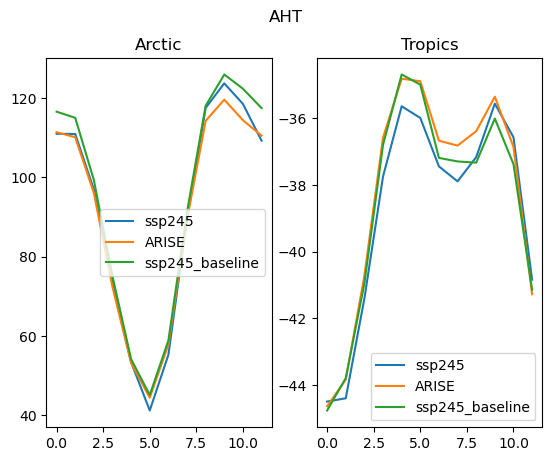

In [4]:
fig, axs = plt.subplots(1, 2)
i=0
for region in regions:
    ax = axs[i]
    for scen in scenarios:
        ax.plot(spatial_means_dict[scen][region].AHT.values, label=scen)
    ax.legend()
    ax.set_title(region)
    i=i+1
plt.suptitle('AHT')

Text(0.5, 0.98, 'OHU')

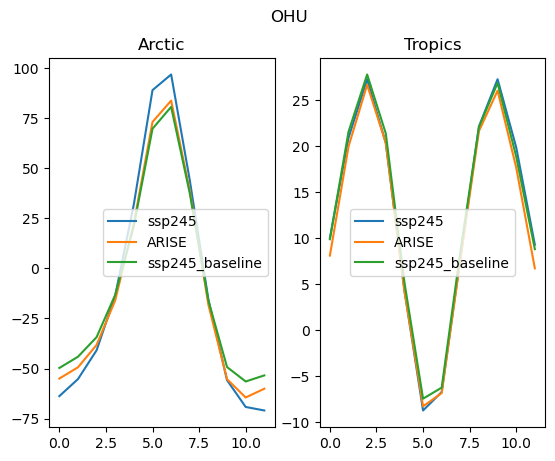

In [5]:
fig, axs = plt.subplots(1, 2)
i=0
for region in regions:
    ax = axs[i]
    for scen in scenarios:
        ax.plot(spatial_means_dict[scen][region].OHU.values, label=scen)
    ax.legend()
    ax.set_title(region)
    i=i+1
plt.suptitle('OHU')

In [6]:
# read in feedbacks (W/m2 - so R units)
Rs_sai = xr.open_dataset('intermediate_outputs/feedbacks/ssp245_ARISE_feedbacks.nc')
Rs_ssp = xr.open_dataset('intermediate_outputs/feedbacks/baseline_ssp245_feedbacks.nc')

def add_extra_Rs(Rs):
    Planck_global_mean_lambda = QACC_utils.calc_spatial_mean(Rs.Planck, 'lon', 'lat')/QACC_utils.calc_spatial_mean(Rs.delta_TS, 'lon', 'lat') # W/m2/K
    Planck_global_mean_cs_lambda = QACC_utils.calc_spatial_mean(Rs.Planck_cs, 'lon', 'lat')/QACC_utils.calc_spatial_mean(Rs.delta_TS, 'lon', 'lat') # W/m2/K

    Planck_global_mean = QACC_utils.calc_spatial_mean(Rs.Planck, 'lon', 'lat') # W/m2
    Planck_global_mean_cs = QACC_utils.calc_spatial_mean(Rs.Planck_cs, 'lon', 'lat') # W/m2
    
    # this one is the real calc
    Rs['Planck_dash'] = (Rs['Planck']/Rs['delta_TS'] - Planck_global_mean_lambda)*Rs['delta_TS'] # keep these in W/m2 units, but global mean planck in W/m2/K units
    Rs['Planck_dash_cs'] = (Rs['Planck_cs']/Rs['delta_TS'] - Planck_global_mean_cs_lambda)*Rs['delta_TS'] # keep these in W/m2 units, but global mean planck in W/m2/K units

    # try simpler (but wrong, i think) planck calc to check it doesn fix things - it doesnt
    #Rs['Planck_dash'] = -(Rs['Planck'] - Planck_global_mean) 
    #Rs['Planck_dash_cs'] = -(Rs['Planck_cs'] - Planck_global_mean_cs) 
    
    Rs_arctic_mean = QACC_utils.calc_spatial_mean(Rs.sel(lat=slice(lat_band_dict['Arctic'][0], lat_band_dict['Arctic'][1])), 'lon', 'lat')
    Rs_tropics_mean = QACC_utils.calc_spatial_mean(Rs.sel(lat=slice(lat_band_dict['Tropics'][0], lat_band_dict['Tropics'][1])), 'lon', 'lat')

    # also save planck mean for later
    Rs_arctic_mean['Planck_global_mean_lambda'] = Planck_global_mean_lambda
    Rs_tropics_mean['Planck_global_mean_lambda'] = Planck_global_mean_lambda
    return Rs, Rs_arctic_mean, Rs_tropics_mean

Rs_sai, Rs_sai_arctic, Rs_sai_tropics = add_extra_Rs(Rs_sai)
Rs_ssp, Rs_ssp_arctic, Rs_ssp_tropics = add_extra_Rs(Rs_ssp)

Rs_dict = {'sai':{'Arctic':Rs_sai_arctic, 'Tropics':Rs_sai_tropics, 'Spatial':Rs_sai},
           'ssp':{'Arctic':Rs_ssp_arctic, 'Tropics':Rs_ssp_tropics, 'Spatial':Rs_ssp}}

In [7]:
Rs_sai_arctic

<xarray.Dataset> Size: 2kB
Dimensions:                    (time: 12)
Coordinates:
  * time                       (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    height                     float64 8B ...
    units                      <U5 20B ...
Data variables: (12/16)
    LR                         (time) float64 96B -4.663 -3.369 ... -6.272
    Planck                     (time) float64 96B 12.23 9.63 ... 16.59 16.21
    WV                         (time) float64 96B -0.2853 -0.3899 ... -0.3404
    Alb                        (time) float64 96B -0.01005 ... -9.017e-05
    LR_cs                      (time) float64 96B -3.607 -2.587 ... -4.958
    Planck_cs                  (time) float64 96B 12.86 10.16 ... 17.7 17.12
    ...                         ...
    q_strat                    (time) float64 96B -0.02312 -0.04868 ... -0.03911
    q_strat_cs                 (time) float64 96B -0.02474 -0.05062 ... -0.04083
    delta_TS                   (time) float64 96B -5.191 -4.106 ... -6.814
    Planck_dash                (time) float64 96B -4.19 -3.52 ... -4.949 -5.336
    Planck_dash_cs             (time) float64 96B -4.935 -4.111 ... -6.233
    Planck_global_mean_lambda  (time) float64 96B -3.162 -3.203 ... -3.162

In [8]:
ds_delta_sm_sai_arctic = (spatial_means_dict['ARISE']['Arctic'] - spatial_means_dict['ssp245']['Arctic']).rename({'month':'time'})
ds_delta_sm_ssp_arctic = (spatial_means_dict['ssp245']['Arctic'] - spatial_means_dict['ssp245_baseline']['Arctic']).rename({'month':'time'})

ds_delta_sm_sai_tropics = (spatial_means_dict['ARISE']['Tropics'] - spatial_means_dict['ssp245']['Tropics']).rename({'month':'time'})
ds_delta_sm_ssp_tropics = (spatial_means_dict['ssp245']['Tropics'] - spatial_means_dict['ssp245_baseline']['Tropics']).rename({'month':'time'})
 

print(ds_delta_sm_sai_arctic.tas.mean('time').item())
print(ds_delta_sm_ssp_arctic.tas.mean('time').item())

print(ds_delta_sm_sai_tropics.tas.mean('time').item())
print(ds_delta_sm_ssp_tropics.tas.mean('time').item())

deltas_dict = {'sai':{'Arctic':ds_delta_sm_sai_arctic, 'Tropics':ds_delta_sm_sai_tropics},
               'ssp':{'Arctic':ds_delta_sm_ssp_arctic, 'Tropics':ds_delta_sm_ssp_tropics}}

-3.7508027092677856
5.231382299270993
-1.479591238254874
1.419335654085027


In [9]:
all_feedbacks = ['Planck', 'Alb', 'LR', 'WV', 'T_strat', 'q_strat']

dict_list = []
for scen in ['sai', 'ssp']:
    ds_list = []
    for region in regions:
        Rs = Rs_dict[scen][region]
        delta_ds = deltas_dict[scen][region]
        feedback_masking = sum([(Rs[str(feedback+'_cs')] - Rs[feedback]) for feedback in all_feedbacks])
        IRF_masking = -1*(delta_ds['IRF_aer_cs'] - delta_ds['IRF_aer'])
        cloud_R = delta_ds['CRE'] + IRF_masking + feedback_masking
        ds_list.append(cloud_R)
    regions_cloudR_dict = dict(zip(regions, ds_list))
    dict_list.append(regions_cloudR_dict)
cloudR_dict = dict(zip(['sai', 'ssp'], dict_list))

In [31]:
def get_delta_T_contribs_dict(scen, region):
    
    Rs = Rs_dict[scen][region]
    ds_delta_sm = deltas_dict[scen][region]
    Planck_global_mean_lambda = Rs['Planck_global_mean_lambda']
    cloud_R = cloudR_dict[scen][region]
    
    delta_T_contribs = {
        'F':-(ds_delta_sm['IRF_aer'] + Rs['T_strat'] + Rs['q_strat'])/Planck_global_mean_lambda, # include strat adjustement, to get F from IRF
        'AHT':-ds_delta_sm['AHT']/Planck_global_mean_lambda,
        'OHU':ds_delta_sm['OHU']/Planck_global_mean_lambda, # our OHU is defined the 'wrong' way round, positive into the ocean
        'Planck':-Rs['Planck_dash']/Planck_global_mean_lambda,
        'Alb':-Rs['Alb']/Planck_global_mean_lambda,
        'LR':-Rs['LR']/Planck_global_mean_lambda,
        'WV':-Rs['WV']/Planck_global_mean_lambda,
        'Cloud':-cloud_R/Planck_global_mean_lambda}
    
    if scen == 'ssp':
        del delta_T_contribs['F'] # F is the aerosol forcing, not meaningful for ssp warming
        
    return delta_T_contribs

In [32]:
## colorscheme for all contributions:
color_scheme = {
     'F': '#e57373',       # Muted red
    'AHT': '#64b5f6',     # Sky blue
    'OHU': '#81c784',     # Mint green
    'Planck': '#ba68c8',  # Soft purple
    'Alb': '#ffb74d',     # Burnt orange
    'LR': '#fff176',      # Pastel yellow
    'WV': '#a1887f',      # Dusty brown
    'Cloud': '#f06292',    # Pale pink
    'Residual':'dimgrey'
}

process_labels = {'F':'F_aer',
                  'AHT':'AHT',
                  'OHU':'OHU',
                  'Planck':'Planck',
                  'Alb':'Albedo',
                  'LR':'Lapse Rate',
                  'WV':'Water vapour',
                  'Cloud':'Cloud'}

In [33]:
matplotlib.rcParams.update({'font.size': 15})

Text(0.5, 1.0, 'ΔT contribitions: sai: Arctic')

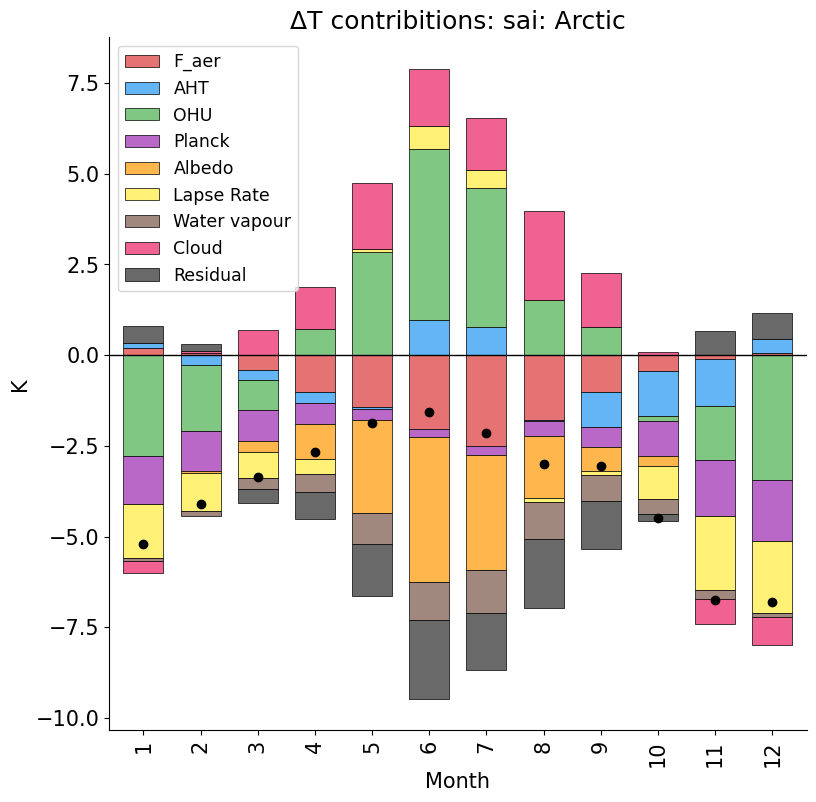

In [34]:
# quick example plot
scen, region = 'sai', 'Arctic'
df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))

df['Month'] = Rs_dict[scen][region].time.values
total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
residuals = deltas_dict[scen][region].tas.values - total_T_contribs
df['Residual'] = residuals

df_rn = df.rename(columns=process_labels) # full words for labels

fig, ax = plt.subplots(1, 1, figsize = (9, 9))#, sharey=True)
i=0
df_rn.plot(kind = "bar",
        x='Month',
        stacked = True,
        ax = ax,
        width = 0.7,
        edgecolor = "black", lw=0.5,
        color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
#ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
ax.set_ylabel('K')
ax.axhline(y=0, c='black', lw=1)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(fontsize='small', loc='upper left', ncols=1)
ax.set_title('ΔT contribitions: {s}: {r}'.format(s=scen, r=region))

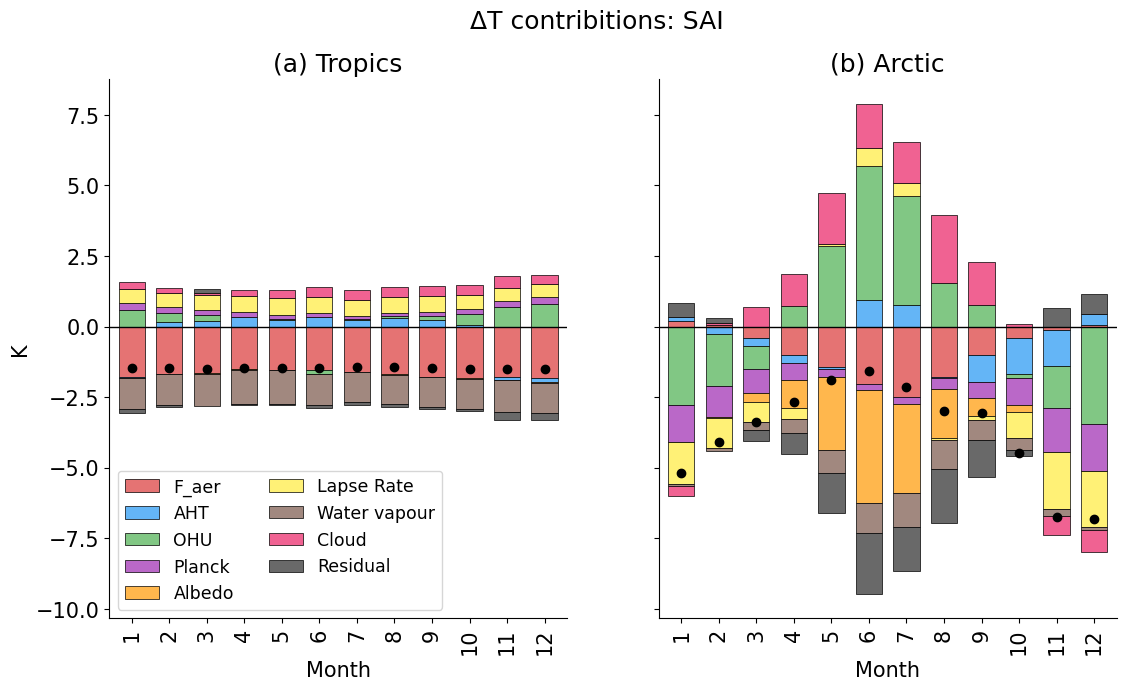

In [35]:
### now plot for both regions:

fig, axs = plt.subplots(1, 2, figsize = (13, 7),
                       sharey=True, sharex=True)

scen = 'sai'
titles = ['(a) Tropics', '(b) Arctic']
i=0
for region in ['Tropics', 'Arctic']:

    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
    df['Month'] = Rs_dict[scen][region].time.values
    total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
    residuals = deltas_dict[scen][region].tas.values - total_T_contribs
    df['Residual'] = residuals
    df_rn = df.rename(columns=process_labels)
    ax = axs[i]
    
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    
    ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    ax.set_ylabel('K')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[i])
    i=i+1

axs[0].legend(fontsize='small', loc='lower left', ncols=2)
plt.suptitle('ΔT contribitions: SAI')

plt.savefig('figures/Arctic_and_tropical_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

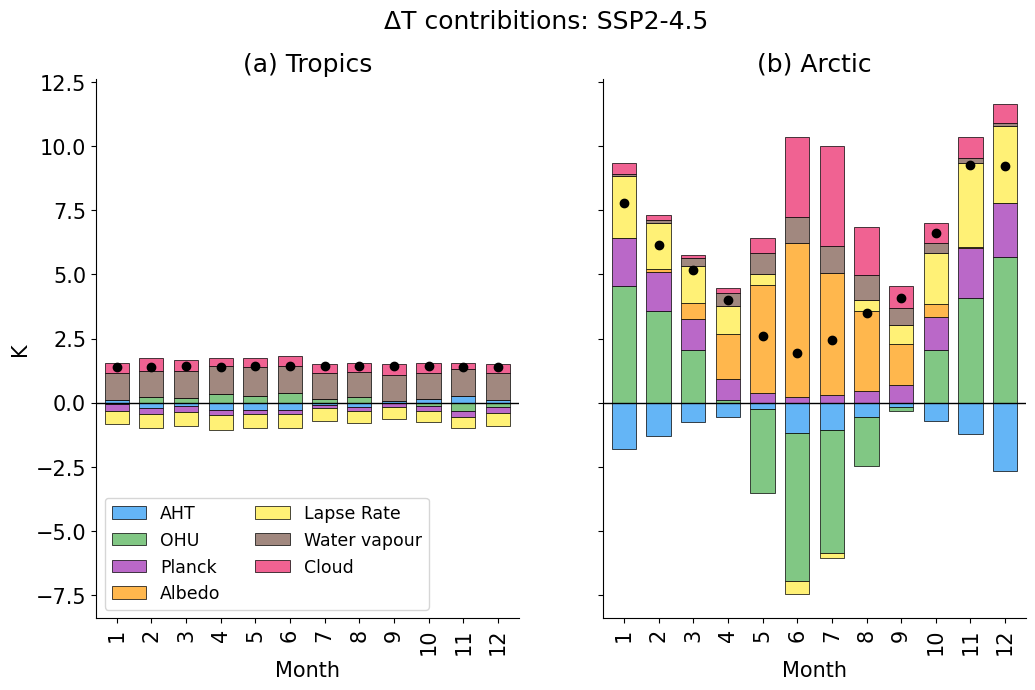

In [36]:
### note - can't do residuals, total T or forcing for SSP cause we dont have it

fig, axs = plt.subplots(1, 2, figsize = (12, 7),
                       sharey=True, sharex=True)

scen = 'ssp'
i=0
titles = ['(a) Tropics', '(b) Arctic']
for region in ['Tropics', 'Arctic']:

    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
    df['Month'] = Rs_dict[scen][region].time.values
    df_rn = df.rename(columns=process_labels)
    #df = df.drop(columns=['F'])
    #total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
    #residuals = deltas_dict[scen][region].tas.values - total_T_contribs
    #df['Residual'] = residuals
    
    ax = axs[i]
    
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    ax.set_ylabel('K')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[i])
    
    i=i+1

axs[0].legend(fontsize='small', loc='lower left', ncols=2)
plt.suptitle('ΔT contribitions: SSP2-4.5')

plt.savefig('figures/Arctic_and_tropical_warming_contribs.jpg', dpi=300, bbox_inches='tight')

In [37]:
scen = 'sai'
df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()

list(df_t)

[-1.6865590946305382,
 0.15658759193395932,
 0.25685351416774527,
 0.17785054469805647,
 -0.01580902085978278,
 0.5319650987008906,
 -1.096675027882652,
 0.293844156453215]

In [38]:
df_t

F        -1.686559
AHT       0.156588
OHU       0.256854
Planck    0.177851
Alb      -0.015809
LR        0.531965
WV       -1.096675
Cloud     0.293844
dtype: float64

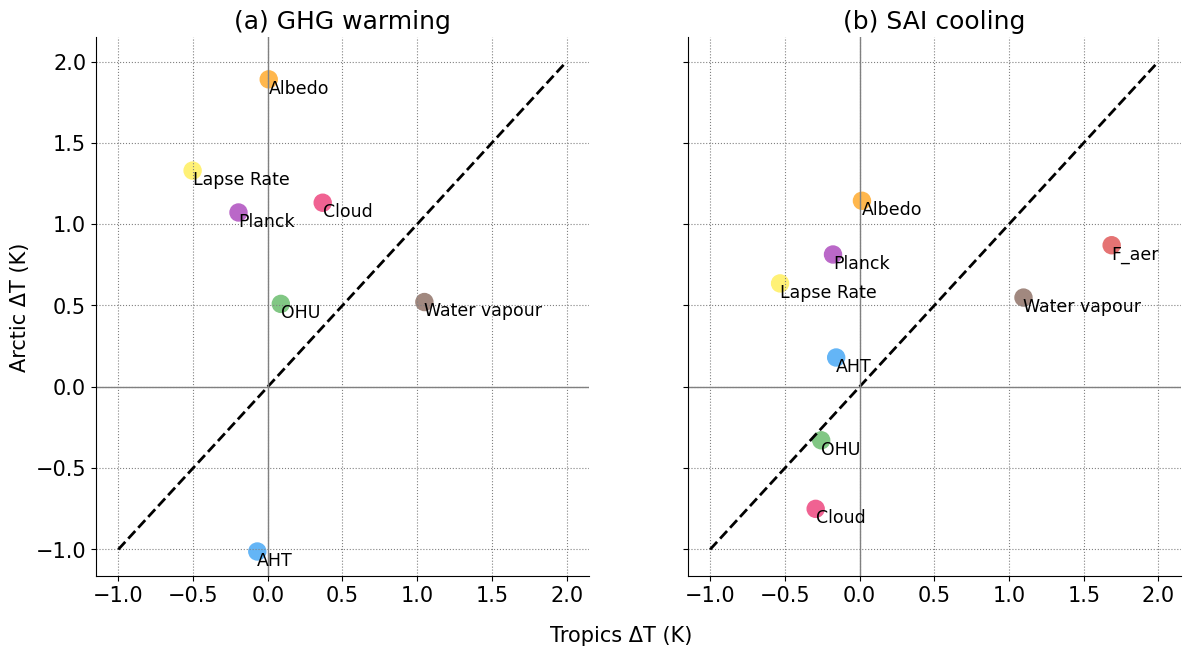

In [39]:
## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(1, 2, figsize = (14, 7),
                       sharey=True, sharex=True)
l=0
titles=['(a) GHG warming', '(b) SAI cooling']
for scen in ['ssp', 'sai']:
    ax = axs[l]
    line = [-1, 2]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
 
    df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()
    df_a = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Arctic')).mean()
    
    if scen == 'ssp':
        ax.scatter(df_t, df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (list(df_t)[i], list(df_a)[i]), va='top', ha='left', fontsize='small')
    elif scen == 'sai':
        ax.scatter(-df_t, -df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (-list(df_t)[i], -list(df_a)[i]), va='top', ha='left', fontsize='small')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(titles[l])
    
    l=l+1

axs[0].set_ylabel('Arctic ΔT (K)', fontsize='medium')
fig.supxlabel('Tropics ΔT (K)', fontsize='medium')
plt.savefig('figures/Arctic_vs_tropical_warming_and_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

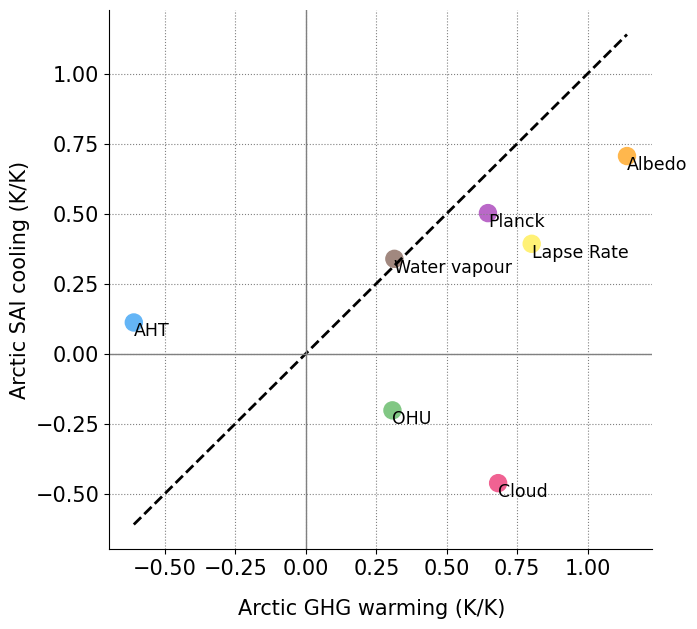

In [40]:

## plot the arctic warming vs arctic cooling contributions under sai

region = 'Arctic'
fig, ax = plt.subplots(1, 1, figsize = (7, 7))

df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')

# normalise by global warming/cooling (this also takes care of the sign): 
df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()


line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
ax.plot(line, line, c='black', linewidth=2, linestyle='--')

ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
    
for i, txt in enumerate(df_x.keys()):
    ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title('')
ax.grid(ls='dotted', c='gray')
ax.axhline(0, c='gray', linewidth=1)
ax.axvline(0, c='gray', linewidth=1)
   
ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
fig.supxlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
plt.savefig('figures/{r}_warming_vs_cooling_contribs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

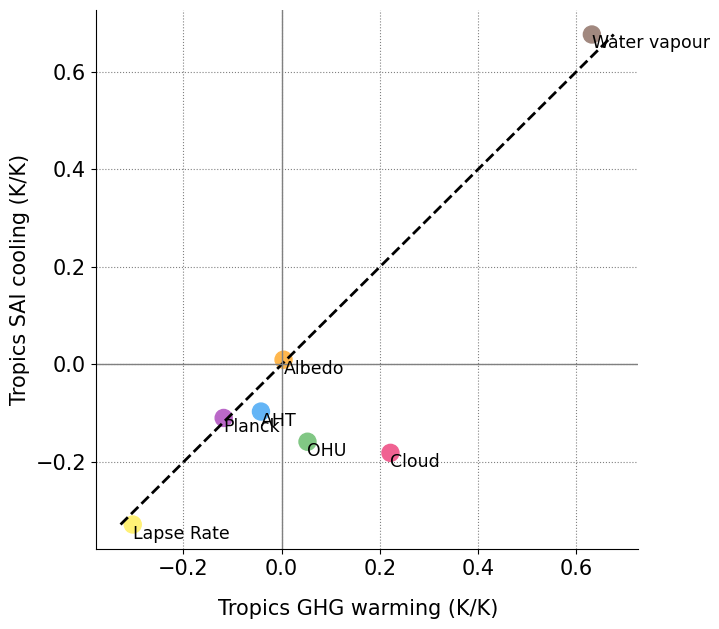

In [41]:

region = 'Tropics'
fig, ax = plt.subplots(1, 1, figsize = (7, 7))

df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')

# normalise by global warming/cooling (this also takes care of the sign): 
df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()

line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
ax.plot(line, line, c='black', linewidth=2, linestyle='--')

ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
    
for i, txt in enumerate(df_x.keys()):
    ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title('')
ax.grid(ls='dotted', c='gray')
ax.axhline(0, c='gray', linewidth=1)
ax.axvline(0, c='gray', linewidth=1)
   
ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
fig.supxlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
plt.savefig('figures/{r}_warming_vs_cooling_contribs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

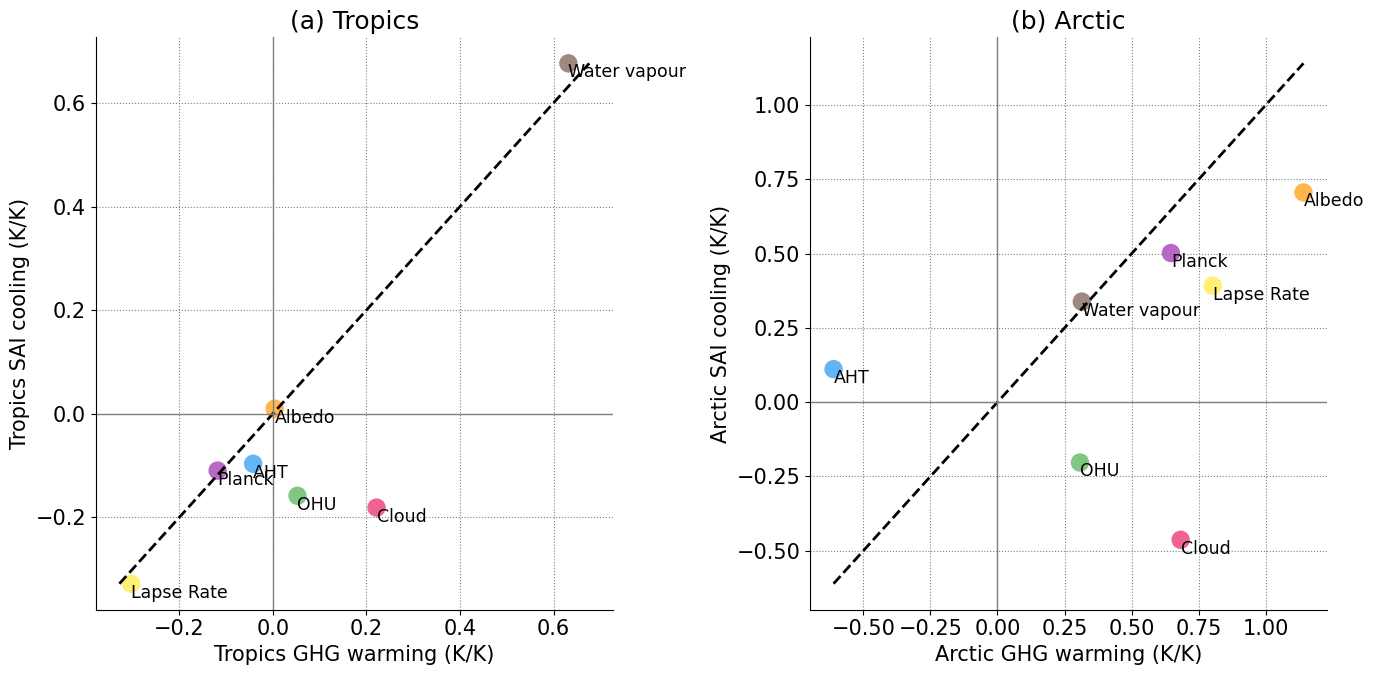

In [42]:
## combine into one:

fig, axs = plt.subplots(1, 2, figsize = (14, 7))

l=0
titles = ['(a) Tropics', '(b) Arctic']
for region in ['Tropics', 'Arctic']:
    ax = axs[l]
 
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')
    
    # normalise by global warming/cooling (this also takes care of the sign): 
    df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1
plt.tight_layout()   
plt.savefig('figures/Both_regs_warming_vs_cooling_contribs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

In [43]:
np.min([np.min(df_x), np.min(df_y)])

-0.6106181850665944

In [44]:
### now add some maps:
Rs_dict['sai']['Spatial']


feedbacks_to_map = ['Cloud', 'Planck_dash', 'Alb', 'LR', 'WV']

cloudR_dict

{'sai': {'Arctic': <xarray.DataArray (time: 12)> Size: 96B
  array([-1.08483389,  0.25816463,  2.27148294,  3.79429146,  6.07919273,
          5.26893209,  4.90900459,  8.25405734,  5.06166191,  0.24949461,
         -2.20042948, -2.40319875])
  Coordinates:
      height   float64 8B 1.5
    * time     (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
      units    <U5 20B 'kg/kg',
  'Tropics': <xarray.DataArray (time: 12)> Size: 96B
  array([0.78649414, 0.57756021, 0.2470033 , 0.71987951, 0.84790202,
         1.2423789 , 1.22289023, 1.1619418 , 1.1717998 , 1.20671511,
         1.41672298, 0.99429234])
  Coordinates:
      height   float64 8B 1.5
    * time     (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
      units    <U5 20B 'kg/kg'},
 'ssp': {'Arctic': <xarray.DataArray (time: 12)> Size: 96B
  array([ 1.28080208,  0.66144627,  0.34618336,  0.58863997,  1.97466978,
         10.41030539, 13.09349467,  6.31870303,  2.88986391,  2.4264096 ,
          2.50081384,  2.37621029])
  Coordinates:
 